# 07 · Effect sizes and uncertainty

Research question: which associations are practically meaningful? Primary evidence is effect size and event-clustered bootstrap intervals. All tests are exploratory; repeated fighters across cards remain dependent.

In [1]:
from pathlib import Path
import sys
import io
import pandas as pd
import numpy as np
from IPython.display import display, Image
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data' / 'raw').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.data_loader import load_raw, profile_sources, verify_raw, TABLES
from src.pipeline import prepare
from src.analysis import *
from src.visualization import *
def show(figure):
    buffer = io.BytesIO()
    figure.savefig(buffer, format='png', bbox_inches='tight')
    display(Image(data=buffer.getvalue()))
    plt.close(figure)

## Prepare cohort

Winner and loser measurements are paired within the same fight.

In [2]:
data = prepare(save=False)
fights, appearances = cohort(data)
print(f"Cohort: {len(fights):,} fights, {fights.event_id.nunique():,} events, {appearances.fighter_id.nunique():,} fighters")
print(f"Date range: {fights.event_date.min():%Y-%m-%d} to {fights.event_date.max():%Y-%m-%d}")

Cohort: 8,820 fights, 783 events, 2,735 fighters
Date range: 1994-03-11 to 2026-08-08


## Paired winner–loser comparisons

Null: paired differences are symmetric about zero for Wilcoxon. Signed-rank tests require symmetry and independent pairs; repeated fighters weaken independence. Holm adjustment covers this family of nine tests. Bootstrap intervals resample events.

In [3]:
from src.statistics import export_statistics
results = export_statistics(data)
display(results['paired_statistics'])

,metric,paired_fights,winner_mean,loser_mean,mean_paired_difference,median_paired_difference,paired_standardized_effect,event_bootstrap_low,event_bootstrap_high,wilcoxon_p,holm_p
0,age,8541,30.029392,30.924375,-0.894983,-0.903509,-0.171993,-1.012911,-0.781132,3.359321e-53,1.343729e-52
1,height_inches,8641,70.309571,70.198820,0.110751,0.000000,0.043656,0.055867,0.166832,4.716700e-05,9.433400e-05
2,reach_inches,7629,72.046009,71.858173,0.187836,0.000000,0.057876,0.114016,0.257645,2.962688e-06,8.888064e-06
3,sig_landed,8643,44.533380,29.475876,15.057503,11.000000,0.661994,14.562095,15.553402,0.000000e+00,0.000000e+00
4,sig_accuracy,8554,0.516849,0.407710,0.109139,0.095455,0.531103,0.104521,0.113533,0.000000e+00,0.000000e+00
5,td_success,8643,1.459331,0.664237,0.795094,0.000000,0.326617,0.745766,0.847120,1.441315e-190,8.647888e-190
6,kd,8643,0.373829,0.058660,0.315168,0.000000,0.473951,0.301336,0.329214,0.000000e+00,0.000000e+00
7,sub_att,8643,0.516025,0.233831,0.282194,0.000000,0.258652,0.259019,0.305210,1.829471e-130,9.147357e-130
8,prior_ufc_fights,8664,5.583102,5.724261,-0.141159,0.000000,-0.021098,-0.294089,0.009788,9.325053e-01,9.325053e-01


## Unequal-attribute matchups

Wilson intervals treat bouts as Bernoulli observations. Event-bootstrap intervals additionally preserve within-card dependence. Neither identifies a causal advantage.

In [4]:
display(results['advantage_uncertainty'])
display(attribute_advantage(fights,'reach_inches').query('unequal_pairs >= 100'))

,attribute,n,advantaged_wins,win_rate,wilson_low,wilson_high,event_bootstrap_low,event_bootstrap_high,excluded_equal_or_missing_or_unresolved
0,age,8537,3662,0.428956,0.418492,0.439485,0.418261,0.439609,283
1,height_inches,7160,3742,0.522626,0.511047,0.534180,0.510476,0.534933,1660
2,reach_inches,6629,3445,0.519686,0.507651,0.531698,0.507720,0.532135,2191


,weight_class,unequal_pairs,advantaged_win_rate,attribute
0,Bantamweight,650,0.495385,reach_inches
2,Featherweight,709,0.509168,reach_inches
3,Flyweight,352,0.474432,reach_inches
4,Heavyweight,516,0.587209,reach_inches
5,Light Heavyweight,572,0.554196,reach_inches
6,Lightweight,1082,0.516636,reach_inches
7,Middleweight,877,0.532497,reach_inches
8,Welterweight,1048,0.526718,reach_inches
9,Women's Bantamweight,186,0.575269,reach_inches
11,Women's Flyweight,234,0.491453,reach_inches


## Division and finishing method

Null: method and division are independent among KO/TKO, submission and decision bouts. Inspect expected cell counts, report Cramér’s V, and acknowledge repeated competitors.

In [5]:
display(results['division_association'])

,question,n,chi_squared,degrees_freedom,p_value,min_expected,cramers_v
0,Division versus method among KO/submission/dec...,8520,471.744699,22,5.593415e-86,20.568075,0.166387


## Physical correlation

Null: no linear/monotonic association between height and reach. Use one row per fighter; pooling divisions can drive correlations.

In [6]:
display(results['physical_correlation'])

,question,n,pearson_r,pearson_p,spearman_r,spearman_p
0,"Height versus reach, one row per observed UFC ...",2079,0.8906,0.0,0.88745,0.0


## Title fights at a common schedule

Compare only standard five-round fights. Mann–Whitney tests distributions, not necessarily means. A small p-value can accompany a small rank-biserial effect; title assignment is not randomized.

In [7]:
display(results['title_statistics'])

,question,title_n,non_title_n,title_mean_minutes,non_title_mean_minutes,mean_difference_minutes,mann_whitney_p,rank_biserial
0,Title vs non-title among standard five-round f...,380,405,15.953816,14.436831,1.516985,0.032941,0.085413


## Research extension: Which physical associations survive adjustment and sensitivity checks?

The following answers are computed from the current snapshot. Tables expose denominators and missingness so the claims can be checked.

In [8]:
from src.research import run_chapter, display_answers
deep_tables, deep_answers = run_chapter('07')
display_answers(deep_answers)

### Does the reach association survive adjustment for other fighter characteristics?

**Answer.** On the same 7,195 complete-case bouts, the crude odds ratio per additional 2 inches of reach is 1.079; the adjusted ratio is 1.066 (250-replicate event-bootstrap 95% interval 1.031-1.105).

**Interpretation.** The exploratory logistic model includes age, height and prior UFC experience differences plus division and decade indicators. Measurements are snapshot traits; missingness, matchup quality and recurring fighters prevent a causal interpretation. Odds ratios are not percentage-point changes.

### Does age still have an association after allowing for UFC experience?

**Answer.** A five-year age difference has adjusted odds ratio 0.711 (interval 0.674-0.748) for the older fighter, holding the included covariates fixed.

**Interpretation.** Age and experience are not interchangeable. Linear log-odds, selected complete cases, mild numerical regularization (C=1,000,000) and residual confounding limit the result.

### How much of the height-reach correlation reflects different divisions?

**Answer.** Among 2,079 unique fighters, pooled Pearson correlation is 0.891; after removing modal-division means it is 0.635.

**Interpretation.** Each fighter appears once and is assigned their most-observed division. The residual correlation measures within-group linear association; athletes competing in multiple divisions make this grouping approximate.

### What happens when comparing reach among similarly aged opponents?

**Answer.** For opponents within two years of age, the longer-reach fighter wins 52.2% across 1,968 bouts.

**Interpretation.** An age caliper is a transparent sensitivity check, not full matching. It changes the eligible population and still leaves division, skill and height differences.

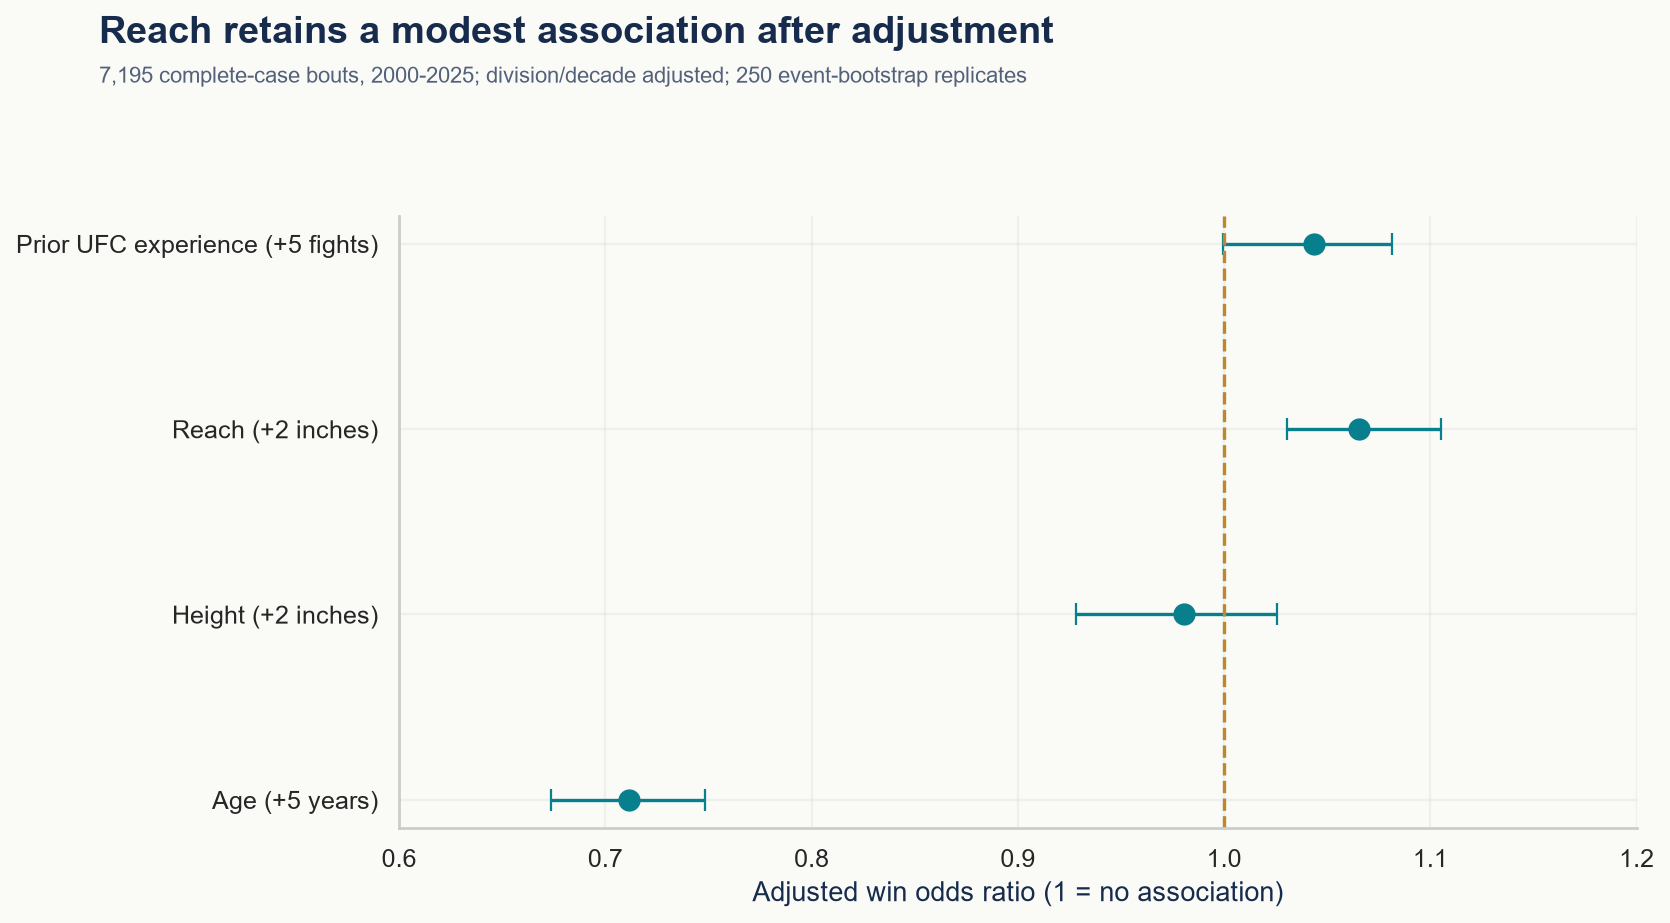

In [9]:
from src.research_visualization import research_chart
show(research_chart('07'))

In [10]:
display(deep_tables['deep_adjusted_attributes'])

,feature,log_odds_coefficient,odds_ratio,event_bootstrap_low,event_bootstrap_high,fights,excluded_from_initial_window,bootstrap_repetitions
0,age_5yr,-0.340742,0.711242,0.673531,0.748234,7195,929,250
1,height_2in,-0.019869,0.980327,0.928096,1.025716,7195,929,250
2,reach_2in,0.063506,1.065566,1.030688,1.104975,7195,929,250
3,experience_5fights,0.042851,1.043783,0.999614,1.081320,7195,929,250


In [11]:
display(deep_tables['deep_within_division_correlation'])

,fighters,pooled_correlation,within_modal_division_correlation
0,2079,0.8906,0.63522


In [12]:
display(deep_tables['deep_reach_age_caliper'])

,maximum_age_gap,fights,longer_reach_win_rate,low,high
0,2,1968,0.522358,0.500267,0.544361
1,5,4366,0.520614,0.505784,0.535408
2,65,6624,0.519928,0.507888,0.531944
